In [2]:
import pandas as pd
import os
from glob import glob

# =========================
# 1. Dateien laden
# =========================

file_paths = glob(r"C:\Users\Max\Documents\BA\Daten\Daten final\*.txt")

print(file_paths)


['C:\\Users\\Max\\Documents\\BA\\Daten\\Daten final\\PEI5mgmL_50°C_Abs.TXT', 'C:\\Users\\Max\\Documents\\BA\\Daten\\Daten final\\PEI5mgmL_50°C_Des.TXT', 'C:\\Users\\Max\\Documents\\BA\\Daten\\Daten final\\PEI5mgmL_60°C_Abs.TXT', 'C:\\Users\\Max\\Documents\\BA\\Daten\\Daten final\\PEI5mgmL_60°C_Des.TXT', 'C:\\Users\\Max\\Documents\\BA\\Daten\\Daten final\\PEI5mgmL_70°C_Abs.TXT', 'C:\\Users\\Max\\Documents\\BA\\Daten\\Daten final\\PEI5mgmL_70°C_Des.TXT', 'C:\\Users\\Max\\Documents\\BA\\Daten\\Daten final\\PEI5mgmL_80°C_Abs.TXT', 'C:\\Users\\Max\\Documents\\BA\\Daten\\Daten final\\PEI5mgmL_80°C_Des.TXT', 'C:\\Users\\Max\\Documents\\BA\\Daten\\Daten final\\PEI5mgmL_90°C_Abs.TXT', 'C:\\Users\\Max\\Documents\\BA\\Daten\\Daten final\\PEI5mgmL_90°C_Des.TXT']


In [3]:
# =========================
# 2. Spaltendefinition
# =========================

columns = [
    "Freq_Hz",
    "Time_s",
    "Eps_real",
    "Eps_imag",
    "Temp_K",
    "MTime_s",
    "Phi_deg",
    "Z_real_Ohm",
    "Z_imag_Ohm",
    "TanPhi"
]

dfs = []

# =========================
# 3. Einlesen + Metadaten aus Dateinamen
# =========================

for path in file_paths:

    df = pd.read_csv(
        path,
        sep=r"\s+",
        skiprows=4,
        names=columns,
        encoding="latin1",
        engine="python"
    )

    # Dateiname ohne Pfad und Extension
    filename = os.path.splitext(os.path.basename(path))[0]

    # Beispiel: PEI5mgmL_90°C_Des
    parts = filename.split("_")

    material = parts[0]
    temperature = parts[1]
    mode = parts[2]

    df["Material"] = material
    df["Temperature"] = temperature
    df["Mode"] = mode

    dfs.append(df)

# =========================
# 4. Zusammenführen
# =========================

df_all = pd.concat(dfs, ignore_index=True)

# =========================
# 5. Spektren-ID (24 Zeilen pro Spektrum)
# =========================

df_all["Spectrum_ID"] = df_all.groupby(
    ["Material", "Temperature", "Mode"]
).cumcount() // 24

# =========================
# 6. Gruppierung für Analyse
# =========================

groups = df_all.groupby(
    ["Material", "Temperature", "Mode", "Spectrum_ID"]
)

# =========================
# 7. Kontrolle
# =========================

#print(df_all.head())
print(df_all)

         Freq_Hz  Time_s  Eps_real  Eps_imag  Temp_K  MTime_s  Phi_deg  \
0         100.00     0.0    6.2162   0.17024  323.15     7.78  -88.431   
1         150.00     0.0    6.1832   0.16396  323.15    10.32  -88.481   
2         225.00     0.0    6.1510   0.16553  323.15    13.14  -88.458   
3         337.50     0.0    6.1199   0.17290  323.15    16.17  -88.382   
4         506.25     0.0    6.0886   0.18860  323.15    18.70  -88.226   
...          ...     ...       ...       ...     ...      ...      ...   
38240   65684.00  9911.7    5.2356   1.03170  363.15  9966.50  -78.852   
38241   98526.00  9911.7    4.8698   1.14890  363.15  9969.20  -76.725   
38242  147790.00  9911.7    4.4598   1.16180  363.15  9974.20  -75.399   
38243  221680.00  9911.7    4.0975   1.06690  363.15  9976.90  -75.406   
38244  332530.00  9911.7    3.7924   0.88917  363.15  9979.30  -76.805   

        Z_real_Ohm  Z_imag_Ohm   TanPhi  Material Temperature Mode  \
0      105710000.0   2895000.0 -36.5140  

Frequenzverlauf

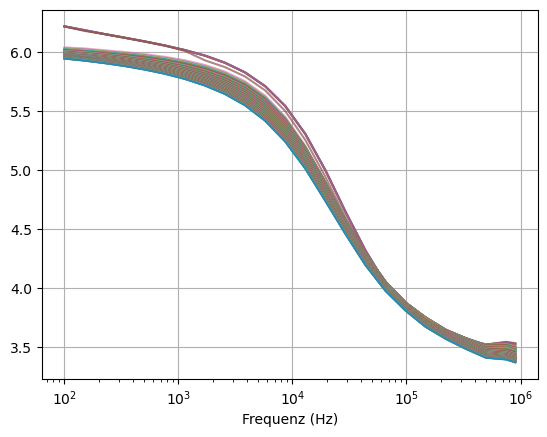

In [4]:
temp = "50°C"
mode = "Abs"

df_sel = df_all[
    (df_all["Temperature"] == temp) &
    (df_all["Mode"] == mode)
]

import matplotlib.pyplot as plt

groups = df_sel.groupby("Spectrum_ID")

plt.figure()

for spec_id, spec in groups:
    plt.plot(
        spec["Freq_Hz"],
        spec["Eps_real"],   # <-- hier Größe wählen
        alpha=0.7
    )

plt.xscale("log")
plt.xlabel("Frequenz (Hz)")
#plt.ylabel("ε''")
#plt.title(f"Spektren - {temp} - {mode}")
plt.grid(True)
plt.show()

Zeitverlauf

Absorption

$\epsilon'$

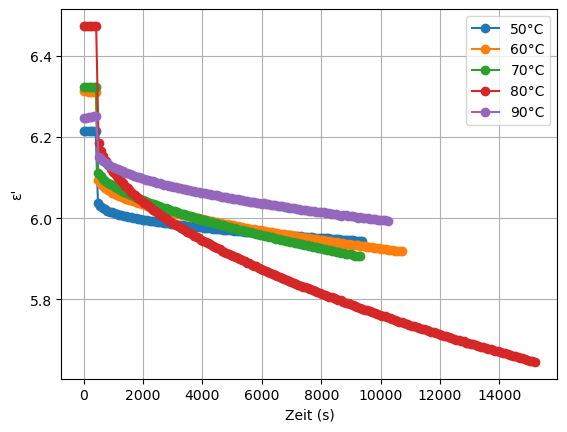

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

f0 = 100
mode = "Abs"
temps = df_all["Temperature"].unique()

plt.figure()

for temp in temps:

    df_sel = df_all[
        (df_all["Temperature"] == temp) &
        (df_all["Mode"] == mode)
    ]

    if df_sel.empty:
        continue

    groups = df_sel.groupby("Spectrum_ID")

    time_series = []

    for spec_id, spec in groups:

        row = spec.loc[(spec["Freq_Hz"] - f0).abs().idxmin()]

        time_series.append([
            spec["MTime_s"].iloc[0],
            row["Eps_real"]
        ])

    eps_time_df = pd.DataFrame(time_series, columns=["Time_s", "Eps_real"])
    eps_time_df = eps_time_df.sort_values("Time_s")

    plt.plot(
        eps_time_df["Time_s"],
        eps_time_df["Eps_real"],
        marker="o",
        label=temp
    )

plt.xlabel("Zeit (s)")
plt.ylabel("ε'")
plt.grid(True)
plt.legend()
plt.show()

$\epsilon''$

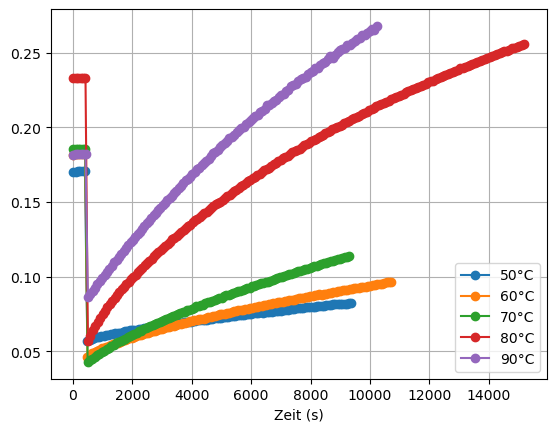

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

f0 = 100
mode = "Abs"
temps = df_all["Temperature"].unique()

plt.figure()

for temp in temps:

    df_sel = df_all[
        (df_all["Temperature"] == temp) &
        (df_all["Mode"] == mode)
    ]

    if df_sel.empty:
        continue

    groups = df_sel.groupby("Spectrum_ID")

    time_series = []

    for spec_id, spec in groups:

        row = spec.loc[(spec["Freq_Hz"] - f0).abs().idxmin()]

        time_series.append([
            spec["MTime_s"].iloc[0],
            row["Eps_imag"]
        ])

    eps_time_df = pd.DataFrame(time_series, columns=["Time_s", "Eps_imag"])
    eps_time_df = eps_time_df.sort_values("Time_s")

    plt.plot(
        eps_time_df["Time_s"],
        eps_time_df["Eps_imag"],
        marker="o",
        label=temp
    )

plt.xlabel("Zeit (s)")
#plt.ylabel("ε'")
plt.grid(True)
plt.legend()
plt.show()

$\epsilon'$

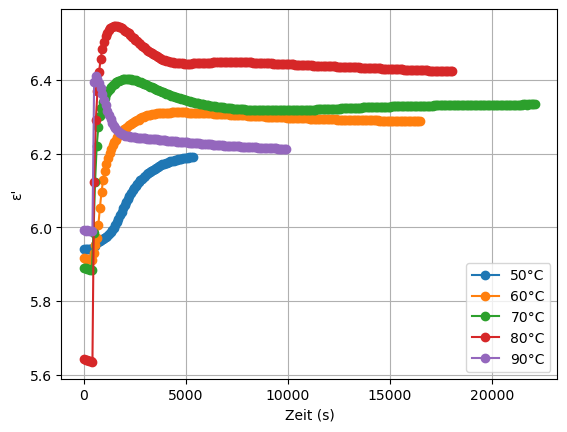

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

f0 = 100
mode = "Des"
temps = df_all["Temperature"].unique()

plt.figure()

for temp in temps:

    df_sel = df_all[
        (df_all["Temperature"] == temp) &
        (df_all["Mode"] == mode)
    ]

    if df_sel.empty:
        continue

    groups = df_sel.groupby("Spectrum_ID")

    time_series = []

    for spec_id, spec in groups:

        row = spec.loc[(spec["Freq_Hz"] - f0).abs().idxmin()]

        time_series.append([
            spec["MTime_s"].iloc[0],
            row["Eps_real"]
        ])

    eps_time_df = pd.DataFrame(time_series, columns=["Time_s", "Eps_real"])
    eps_time_df = eps_time_df.sort_values("Time_s")

    plt.plot(
        eps_time_df["Time_s"],
        eps_time_df["Eps_real"],
        marker="o",
        label=temp
    )

plt.xlabel("Zeit (s)")
plt.ylabel("ε'")
plt.grid(True)
plt.legend()
plt.show()

$\epsilon''$

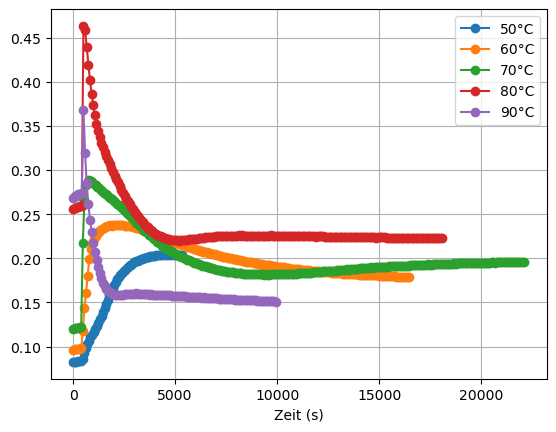

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

f0 = 100
mode = "Des"
temps = df_all["Temperature"].unique()

plt.figure()

for temp in temps:

    df_sel = df_all[
        (df_all["Temperature"] == temp) &
        (df_all["Mode"] == mode)
    ]

    if df_sel.empty:
        continue

    groups = df_sel.groupby("Spectrum_ID")

    time_series = []

    for spec_id, spec in groups:

        row = spec.loc[(spec["Freq_Hz"] - f0).abs().idxmin()]

        time_series.append([
            spec["MTime_s"].iloc[0],
            row["Eps_imag"]
        ])

    eps_time_df = pd.DataFrame(time_series, columns=["Time_s", "Eps_imag"])
    eps_time_df = eps_time_df.sort_values("Time_s")

    plt.plot(
        eps_time_df["Time_s"],
        eps_time_df["Eps_imag"],
        marker="o",
        label=temp
    )

plt.xlabel("Zeit (s)")
#plt.ylabel("ε'")
plt.grid(True)
plt.legend()
plt.show()

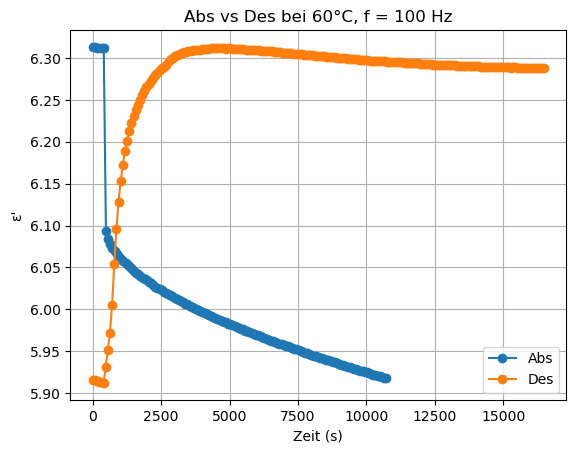

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# Parameter
# =========================

f0 = 100
temp = "60°C"

modes = ["Abs", "Des"]

plt.figure()

# =========================
# Loop über Abs / Des
# =========================

for mode in modes:

    df_sel = df_all[
        (df_all["Temperature"] == temp) &
        (df_all["Mode"] == mode)
    ]

    if df_sel.empty:
        continue

    groups = df_sel.groupby("Spectrum_ID")

    time_series = []

    for spec_id, spec in groups:

        row = spec.loc[(spec["Freq_Hz"] - f0).abs().idxmin()]

        time_series.append([
            spec["MTime_s"].iloc[0],
            row["Eps_real"]
        ])

    eps_time_df = pd.DataFrame(time_series, columns=["Time_s", "Eps_real"])
    eps_time_df = eps_time_df.sort_values("Time_s")

    plt.plot(
        eps_time_df["Time_s"],
        eps_time_df["Eps_real"],
        marker="o",
        label=mode
    )

# =========================
# Plot Styling
# =========================

plt.xlabel("Zeit (s)")
plt.ylabel("ε'")
plt.title(f"Abs vs Des bei {temp}, f = {f0} Hz")
plt.grid(True)
plt.legend()

plt.show()